# Module 3 — One Tree Model, Interpreted with Permutation Importance

## Why you're here: what the model is for
- Same bank, same question as Module 2: what goes together with `default`
  (1 = the bank recorded the client as defaulting in October; the dataset never
  defines exactly what counts as default)?
- Module 2's logistic regression assumes each extra unit of a column multiplies
  the odds by the **same** amount. For `late_sep` (months late in September) that
  broke: default jumps from 0 to 1 to 2 months late, then flattens.
- A **tree model** makes no such assumption. It learns rules like "if `late_sep`
  is 2 or more, high risk" straight from the data, so it can follow jumps, flat
  stretches, and combinations of columns.
- The catch: a tree model has **no coefficients** to read. To see which columns
  matter, we use **permutation importance**: shuffle one column and measure how
  much the model's grade drops.

**Your endgame in this module:** fit one tree model, compare it fairly with
Module 2's logistic regression on the validation rows, and rank its drivers
honestly, including why the built-in ranking misleads and what overlapping
columns do to importance.

## From the curriculum

> ### <u>Module 3 — One Tree Model, Interpreted with Permutation Importance</u>
>
> **Concepts**
> - A decision tree as a set of if/then splits; a Random Forest as many trees
>   averaged (one model, used as-is, not a tour of ensembles)
> - What a tree captures that a linear model misses: thresholds and interactions
> - Impurity-based importance (built into the forest) vs. permutation importance
>   (measured on the validation rows), and why the first is biased
> - Overlapping columns share or hide their importance, so overlapping columns
>   are shuffled together as a group
>
> **Why it matters**
> "Which columns matter most?" is the tree-model version of driver analysis. The
> default importance plot is the one most often shown, and the one most often
> wrong.
>
> **Worked example**
> A Random Forest on the credit data, compared with Module 2's logistic
> regression on validation AUC. Then the forest's built-in importances vs.
> permutation importances on the validation set, and grouped permutation of the
> six correlated repayment-status columns.
>
> **Resources**
> - [Permutation feature importance](https://scikit-learn.org/stable/modules/permutation_importance.html)
>   (scikit-learn user guide §5.2, ~15 min, verified). Covers exactly the two
>   traps in this module: impurity bias and correlated features.
>
> **Exercise type:** compare-and-reconcile: where the forest's drivers agree or
> disagree with Module 2's regression, and why.
>
> **Interview angle:** "How do you explain a black-box model (one whose internal
> reasoning can't be read directly, like a forest) to a stakeholder?" / "What's
> wrong with the **built-in importance ranking** a model gives you by default?"
> (interviewers often phrase it as "what's wrong with feature importance?")

## Lesson

### A decision tree
1. **A sequence of yes/no questions about the columns.** For example: "is
   `late_sep` 2 or more?" Each question splits the clients into two groups.
2. **How a question is chosen.** At each step the tree tries every column and
   every cut-off, and picks the question whose two groups separate defaulters
   from payers best, measured on the training rows.
3. **Leaves.** The questions stop when a limit is hit: a maximum number of
   questions in a row, a minimum number of clients per leaf, or no question
   improving the split. Each final group is then a **leaf**. A leaf's prediction
   is the share of defaulters among the training clients who landed in it.
4. **Combinations come for free.** A question asked *inside* one group applies
   only to that group ("among clients 2+ months late, is the bill above X?"). That's
   an **interaction**: one column's link to default depends on another column.
   Logistic regression doesn't do that unless you build the combination yourself.

### Over-fitting
A tree allowed to keep asking questions will eventually make a leaf for every
few clients, and memorise the training rows, quirks included. That's
**over-fitting**. The sign: a near-perfect grade on the training rows and a worse
grade on hidden rows. The quirks don't repeat in new clients.

### A random forest
1. **Many trees** (here 300), each trained on its own random sample of the
   training rows: **18,000 rows drawn with replacement** from the 18,000 training
   clients. So some clients appear twice and about 37% don't appear at all
   (each client's chance of never being drawn is (1 − 1/18,000)^18,000 ≈ 36.8%).
   Each tree also chooses its questions from a random subset of the columns.
2. **The forest's prediction** for a client is the average of its trees'
   predictions. Individual trees' quirks point in different directions and
   largely cancel out.
3. **An ensemble.** A model built by combining many models is called an
   **ensemble**; a forest is one. (Others exist, such as gradient boosting, where
   trees are built one after another, each correcting the previous ones. This
   module uses the forest only.)
4. **The one setting we choose**, `min_samples_leaf`: the smallest number of
   training clients allowed in a leaf. It stops the trees from memorising
   handfuls of clients.

### Importance: which columns does the model rely on?
A forest has no coefficients. Two ways to measure each column's importance:
- **Built-in ("impurity") importance (shown in this module as a trap):** how much each column's questions
  improved the separation *inside the training rows*. It's quick, but it's
  measured on rows the model memorised partly, and it favours columns with many
  distinct values (amounts, ages), because they offer more possible cut-offs.
- **Permutation importance:** take the validation rows, **shuffle one column's
  values** across clients (so that column no longer matches the right client),
  and grade the model again. The **drop in AUC** is that column's importance: how
  much the model's ranking relied on it. A drop near 0 means the model barely
  used it.

### When columns overlap
If two columns carry the same information, shuffling one leaves the other
intact, so the model barely suffers and **both** look unimportant. The fix is to
shuffle the overlapping columns **together**, as one group.

### Still not a cause
Importance says what the model **relied on** to rank clients, not what causes
default. It's association, exactly as in Module 2.

### Part 0 — The data and the prepared columns
The same credit data and the same locked split as Module 2 (from `common.py`):
18,000 training rows, 6,000 validation rows, and 6,000 test rows that stay
untouched until Module 6. All the quality issues listed in Module 2's Part 0
still apply.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score

from common import load_credit, credit_split, prepare_credit

BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "figure.dpi": 110})

train, valid, test = credit_split(load_credit())
X_train, y_train = prepare_credit(train), train["default"]
X_valid, y_valid = prepare_credit(valid), valid["default"]
print(f"training rows: {len(X_train):,}   validation rows: {len(X_valid):,}")
print("The same three clients as Module 2's sample (1, 2 and 3319), now with the prepared columns:")
print(X_train.loc[[1, 2, 3319]].to_string())

training rows: 18,000   validation rows: 6,000
The same three clients as Module 2's sample (1, 2 and 3319), now with the prepared columns:
      limit_k  age  female  married  edu_graduate  edu_highschool  edu_other  late_sep  late_aug  late_jul  late_jun  late_may  late_apr  bill_sep_k  paid_sep_k
ID                                                                                                                                                              
1        20.0   24       1        1             0               0          0         2         2         0         0         0         0       3.913       0.000
2       120.0   26       1        0             0               0          0         0         2         0         0         0         2       2.682       0.000
3319    200.0   36       0        1             0               0          0         2         0         0         0         0         0       7.300       3.238


**The prepared columns** (built by `prepare_credit` in `common.py`):

| Name | Built from | Meaning |
|---|---|---|
| `limit_k` | `LIMIT_BAL` ÷ 1,000 | credit limit, thousands of NT$ |
| `age` | `AGE` | age in years |
| `female` | `SEX` = 2 | 1 = female, 0 = male |
| `married` | `MARRIAGE` = 1 | 1 = married, 0 = not |
| `edu_graduate`, `edu_highschool`, `edu_other` | `EDUCATION` | 1 = in that education group; university is the group with no column |
| `late_sep`, `late_aug`, `late_jul`, `late_jun`, `late_may`, `late_apr` | `PAY_1` … `PAY_6`, negatives set to 0 | months late in that month (0–8) |
| `bill_sep_k` | `BILL_AMT1` ÷ 1,000 | September bill, thousands of NT$ |
| `paid_sep_k` | `PAY_AMT1` ÷ 1,000 | amount paid in September, thousands of NT$ |

**One change from Module 2:** Module 2 used only September's and August's
lateness, because the earlier months seem to be coded differently (code 1 is
almost absent). Here all six months are included, for two reasons: a forest
doesn't need readable coefficients, and the six overlapping lateness columns are
exactly what Part 5 needs to show how overlap hides importance. The coding
caveat still applies to the earlier months individually.

### Part 1 — One small tree you can read
A tree limited to two questions in a row (`max_depth=2`), fitted on the training
rows. **This small tree is only for reading. It is not the model used from Part 2
on.** **The questions stop because of that limit:** question 1 splits all clients
into two groups, one more question splits each of those, and then no path may go
deeper. That's 3 questions and 4 leaves. Each line below is one leaf: the
questions that lead to it, how many training clients landed there, and their
default rate, which is the tree's prediction for anyone in that leaf.

In [2]:
small_tree = DecisionTreeClassifier(max_depth=2, random_state=0).fit(X_train, y_train)

t = small_tree.tree_
names = X_train.columns
def leaves(node=0, path=()):
    if t.children_left[node] == -1:                     # a leaf
        yield path, node
        return
    col, cut = names[t.feature[node]], t.threshold[node]
    yield from leaves(t.children_left[node], path + (f"{col} <= {cut:.2f}",))
    yield from leaves(t.children_right[node], path + (f"{col} > {cut:.2f}",))

leaf_of_client = small_tree.apply(X_train)
rows = []
for path, node in leaves():
    in_leaf = leaf_of_client == node
    rows.append({"rule": "  AND  ".join(path), "clients": in_leaf.sum(), "default rate": y_train[in_leaf].mean()})
print(pd.DataFrame(rows).round(3).to_string(index=False))
print(f"\nAll training clients: {len(y_train):,}, default rate {y_train.mean():.3f}")

                                    rule  clients  default rate
 late_sep <= 1.50  AND  late_aug <= 1.50    14755         0.143
  late_sep <= 1.50  AND  late_aug > 1.50     1380         0.410
late_sep > 1.50  AND  bill_sep_k <= 2.21      164         0.500
 late_sep > 1.50  AND  bill_sep_k > 2.21     1701         0.718

All training clients: 18,000, default rate 0.221


**Reading it:**
- The tree's first question is `late_sep` (months late in September), the same
  column Module 2 found strongest. It cuts at 1.5, i.e. "2 or more months late".
- Among clients less than 2 months late, it next asks about **August**: those
  2+ months late in August default at 41.0%, against 14.3% for the rest.
- Among clients 2+ months late in September, it asks about the **bill**: above
  2.21k NT$, 71.8% default; at or below, 50.0% (only 164 clients).

**Observation:** the bill question is only asked *inside* the "2+ months late"
group. That's an interaction: the September bill goes with extra risk only for
clients who are already behind.

**Hypothesis:** a late client with a large
balance owes more than they can clear; a late client with a tiny bill can catch
up. The data can't confirm it.

### Part 2 — The forest, and its two settings
**A forest, in three lines:**
1. Build many trees, each on its own random sample of the training clients, each
   picking its questions from a random few columns at every step.
2. For a new client, every tree gives an answer: the default rate of the leaf that
   client lands in.
3. The forest's prediction is the average of all the trees' answers.

It has two settings to choose: **how many trees** (`n_estimators`) and **the
smallest leaf allowed** (`min_samples_leaf`). Both are tested below on the
validation rows.

**Setting 1: how many trees.** Six forests, identical except for the number of
trees (each with leaves of at least 50 clients, the leaf size chosen in Setting 2;
the pattern is the same at other leaf sizes):

In [3]:
counts = []
for n in [1, 10, 50, 100, 300, 1000]:
    rf = RandomForestClassifier(n_estimators=n, min_samples_leaf=50, n_jobs=-1, random_state=0).fit(X_train, y_train)
    counts.append({"trees": n, "AUC on validation rows": roc_auc_score(y_valid, rf.predict_proba(X_valid)[:, 1])})
print(pd.DataFrame(counts).round(4).to_string(index=False))

 trees  AUC on validation rows
     1                  0.7553
    10                  0.7772
    50                  0.7823
   100                  0.7827
   300                  0.7830
  1000                  0.7833


**Observation:** more trees never hurt the grade, because averaging more trees only
makes the average steadier. But the gain flattens quickly: most of it arrives by
50 trees, and from 100 to 1,000 trees the AUC barely moves.

**The choice:** 300 trees. It sits safely in the flat part, and on this data even
1,000 trees train in a few seconds. The number of trees isn't fine-tuned, just
made large enough.

**Setting 2: the smallest leaf.** The forest's trees have **no depth limit**
(unlike Part 1's small tree). They stop only when a leaf would have fewer than
`min_samples_leaf` clients. Four forests with 300 trees, identical except for
`min_samples_leaf`, each graded on the training rows it learned from and on the
validation rows it never saw:

In [4]:
settings = []
for leaf in [1, 20, 50, 100]:
    rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=leaf, n_jobs=-1, random_state=0).fit(X_train, y_train)
    settings.append({"min_samples_leaf": leaf,
                     "AUC on training rows": roc_auc_score(y_train, rf.predict_proba(X_train)[:, 1]),
                     "AUC on validation rows": roc_auc_score(y_valid, rf.predict_proba(X_valid)[:, 1])})
print(pd.DataFrame(settings).round(4).to_string(index=False))

 min_samples_leaf  AUC on training rows  AUC on validation rows
                1                1.0000                  0.7505
               20                0.8361                  0.7832
               50                0.8039                  0.7830
              100                0.7909                  0.7822


**Observation:** with `min_samples_leaf=1` (leaves as small as one client) the
forest scores a perfect 1.0 on the training rows and only 0.7505 on validation:
textbook over-fitting. With leaves of at least 20 to 100 clients, validation
AUC sits between 0.7822 and 0.7832, differences smaller than the luck of which
rows were hidden.

**The choice:** `min_samples_leaf=50`. Its validation AUC is within 0.0002 of the
best, and larger leaves memorise less. This choice was made by comparing on the
validation rows, which is what they're for.

In [5]:
forest = RandomForestClassifier(n_estimators=300, min_samples_leaf=50, n_jobs=-1, random_state=0).fit(X_train, y_train)
auc_forest = roc_auc_score(y_valid, forest.predict_proba(X_valid)[:, 1])
print(f"Forest, validation AUC: {auc_forest:.4f}")

Forest, validation AUC: 0.7830


### Part 3 — Forest vs Module 2's logistic regression, fairly
A fair comparison gives both models **the same columns**. Module 2's model had 11
columns (only September and August lateness); the forest above has 15. So each
model type is fitted twice, once with each column set, and all four are graded on
the same validation rows (each model type keeps its own settings; only the columns
change):

In [6]:
part2_columns = ["limit_k", "age", "female", "married", "edu_graduate", "edu_highschool", "edu_other",
                 "late_sep", "late_aug", "bill_sep_k", "paid_sep_k"]
all_columns = list(X_train.columns)

fair, preds = [], {}
for label, cols in [("Module 2's 11 columns", part2_columns), ("all 15 columns", all_columns)]:
    logit = sm.Logit(y_train, sm.add_constant(X_train[cols])).fit(disp=0)
    rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=50, n_jobs=-1, random_state=0).fit(X_train[cols], y_train)
    p_logit = logit.predict(sm.add_constant(X_valid[cols])).to_numpy()
    p_rf = rf.predict_proba(X_valid[cols])[:, 1]
    preds[label] = (p_logit, p_rf)
    a_logit, a_rf = roc_auc_score(y_valid, p_logit), roc_auc_score(y_valid, p_rf)
    fair.append({"columns": label, "logistic regression": a_logit, "forest": a_rf, "forest minus logistic": a_rf - a_logit})
    if label == "all 15 columns":
        logit_all = logit
print(pd.DataFrame(fair).round(4).to_string(index=False))

print("\nIs the forest's lead just luck? 300 made-up groups of 6,000 clients were built by")
print("picking from the 6,000 validation clients at random, where the same client can be")
print("picked more than once. Both models were graded on each group:\n")
yv = y_valid.to_numpy()
rng_boot = np.random.default_rng(3)
groups = [rng_boot.integers(0, len(yv), len(yv)) for _ in range(300)]
print(f"{'':<24}{'average lead':<15}{'lead, middle 95%':<20}groups where the forest led")
averages = {}
for label, (p_logit, p_rf) in preds.items():
    leads = np.array([roc_auc_score(yv[g], p_rf[g]) - roc_auc_score(yv[g], p_logit[g]) for g in groups])
    low, high = np.percentile(leads, [2.5, 97.5])
    averages[label] = leads.mean()
    print(f"{label:<24}{leads.mean():<15.4f}{f'{low:.4f} to {high:.4f}':<20}{(leads > 0).sum()} of {len(leads)}")
single = {row["columns"]: row["forest minus logistic"] for row in fair}
print(f"\nThe average leads are close to the single leads in the table above "
      f"({single["Module 2's 11 columns"]:.4f} and {single['all 15 columns']:.4f})")
print("by design: each client is picked about once per group on average, so the")
print("made-up groups average out to the original one.")
print("\nIn plain words: the forest led in every one of the 300 groups, with both column")
print("sets. The lead isn't luck.")

              columns  logistic regression  forest  forest minus logistic
Module 2's 11 columns               0.7447   0.768                 0.0233
       all 15 columns               0.7575   0.783                 0.0255

Is the forest's lead just luck? 300 made-up groups of 6,000 clients were built by
picking from the 6,000 validation clients at random, where the same client can be
picked more than once. Both models were graded on each group:

                        average lead   lead, middle 95%    groups where the forest led


Module 2's 11 columns   0.0232         0.0136 to 0.0328    300 of 300


all 15 columns          0.0254         0.0167 to 0.0347    300 of 300

The average leads are close to the single leads in the table above (0.0233 and 0.0255)
by design: each client is picked about once per group on average, so the
made-up groups average out to the original one.

In plain words: the forest led in every one of the 300 groups, with both column
sets. The lead isn't luck.


**Observation:** with the same columns, the forest ranks clients better in both
cases, by 0.0233 with Module 2's 11 columns and 0.0255 with all 15. With both
column sets, the forest led in all 300 made-up groups of validation clients, so
the lead isn't the luck of which clients were hidden. Module 2's
model scored 0.7447 on the same validation rows (first row, logistic regression).

In Module 2, logistic regression **overshot** the real default rate for clients 3
or more months late in September, so here the validation clients are grouped by
months late (`late_sep`) to see **whether the forest succeeds where logistic regression failed**:
each group's real default rate against both models' average predictions (both
with all 15 columns).

    clients  actual default rate  logistic regression  forest
0      4654                0.141                0.142   0.146
1       722                0.330                0.357   0.339
2       523                0.696                0.622   0.635
3        65                0.692                0.851   0.681
4+       36                0.667                0.963   0.680


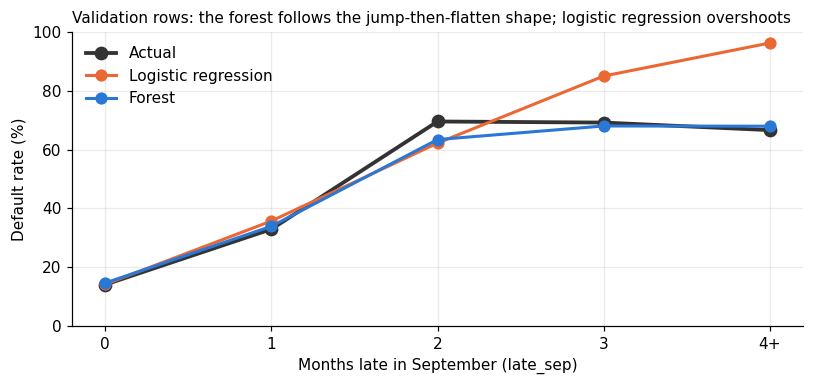

In [7]:
group = X_valid["late_sep"].clip(upper=4)
shape = pd.DataFrame({
    "clients": y_valid.groupby(group).size(),
    "actual default rate": y_valid.groupby(group).mean(),
    "logistic regression": pd.Series(logit_all.predict(sm.add_constant(X_valid[all_columns])), index=X_valid.index).groupby(group).mean(),
    "forest": pd.Series(forest.predict_proba(X_valid)[:, 1], index=X_valid.index).groupby(group).mean(),
})
shape.index = ["0", "1", "2", "3", "4+"]
print(shape.round(3).to_string())

fig, ax = plt.subplots(figsize=(7.5, 3.6))
x = np.arange(len(shape))
ax.plot(x, shape["actual default rate"] * 100, marker="o", markersize=8, linewidth=2.5, color="#333333", label="Actual")
ax.plot(x, shape["logistic regression"] * 100, marker="o", markersize=7, linewidth=2, color=ORANGE, label="Logistic regression")
ax.plot(x, shape["forest"] * 100, marker="o", markersize=7, linewidth=2, color=BLUE, label="Forest")
ax.set_xticks(x, shape.index); ax.set_xlabel("Months late in September (late_sep)")
ax.set_ylabel("Default rate (%)"); ax.set_ylim(0, 100)
ax.legend(frameon=False, loc="upper left")
ax.set_title("Validation rows: the forest follows the jump-then-flatten shape; logistic regression overshoots", fontsize=10, loc="left")
plt.tight_layout(); plt.show()

**Observation:** at 0 and 1 months late all three roughly agree. From 2 months on, the
actual rate flattens around 67–70%. The forest flattens with it, while logistic
regression keeps climbing, to the prediction printed in the "4+" row above.

**Conclusion:** this is the promise from Module 2 kept. A tree model follows a
jump-then-flatten shape without being told about it, because its questions
create steps rather than a single multiplier.

### Part 4 — Which columns does the forest rely on? Two answers
The same forest, ranked two ways: its built-in importance (from the training
rows), and permutation importance (each column shuffled 10 times on the
validation rows; the table shows the average AUC drop over the 10 shuffles, and
its STDEV: how much the drop varied from one shuffle to the next).

In [8]:
builtin = pd.Series(forest.feature_importances_, index=all_columns)
perm = permutation_importance(forest, X_valid, y_valid, scoring="roc_auc", n_repeats=10, random_state=0)
perm_mean = pd.Series(perm.importances_mean, index=all_columns)
perm_std = pd.Series(perm.importances_std, index=all_columns)

ranking = pd.DataFrame({
    "built-in importance": builtin.round(3),
    "built-in rank": builtin.rank(ascending=False).astype(int),
    "permutation: average AUC drop, 10 shuffles": perm_mean.round(4),
    "permutation: STDEV of AUC drop, 10 shuffles": perm_std.round(4),
    "permutation rank": perm_mean.rank(ascending=False).astype(int),
}).sort_values("permutation: average AUC drop, 10 shuffles", ascending=False)
print(ranking.to_string())

                built-in importance  built-in rank  permutation: average AUC drop, 10 shuffles  permutation: STDEV of AUC drop, 10 shuffles  permutation rank
late_sep                      0.373              1                                      0.0764                                       0.0034                 1
limit_k                       0.045              8                                      0.0192                                       0.0027                 2
late_aug                      0.161              2                                      0.0188                                       0.0024                 3
paid_sep_k                    0.066              4                                      0.0171                                       0.0033                 4
bill_sep_k                    0.050              7                                      0.0159                                       0.0025                 5
late_jul                      0.105              3  

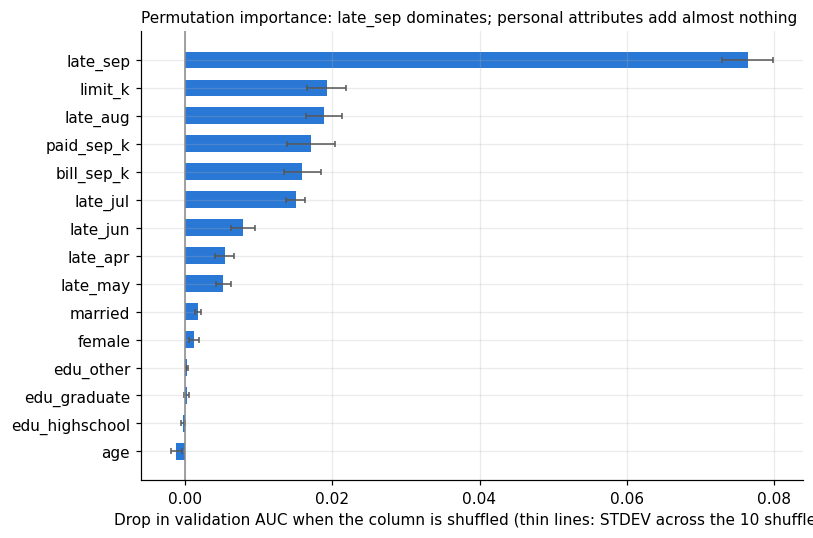

In [9]:
order = perm_mean.sort_values()
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.barh(order.index, order.values, xerr=perm_std[order.index].values, color=BLUE, height=0.6,
        error_kw={"ecolor": "#555555", "capsize": 2, "linewidth": 1})
ax.axvline(0, color="#888888", linewidth=1)
ax.set_xlabel("Drop in validation AUC when the column is shuffled (thin lines: STDEV across the 10 shuffles)")
ax.set_title("Permutation importance: late_sep dominates; personal attributes add almost nothing", fontsize=10, loc="left")
plt.tight_layout(); plt.show()

**Observation:** the two rankings disagree where the Lesson said they would.
- **`limit_k`** is 8th by built-in importance but 2nd by permutation. The forest
  relies on it heavily when ranking new clients.
- **`late_jul`, `late_may`, `late_jun`** rank 3rd, 5th and 6th built-in, but lower
  by permutation: 6th, 9th and 7th. Their built-in scores were earned inside the
  training rows.
- **`age`** has a slightly *negative* drop: shuffling it made the grade marginally
  better. That's noise around zero. The forest gains nothing from age.

**Conclusion:** use permutation importance, measured on the validation rows, to
rank drivers. The built-in ranking reflects how the trees split the training rows,
not what helps on new clients.

### Part 5 — Overlapping columns hide their importance
**How to tell that columns overlap:** one column largely predicts another. Signs
to check: a correlation of about 0.7 or more between them, a VIF above 5–10
(Module 2), or columns that measure the same thing at different times, like the
six monthly lateness columns here.

The six lateness columns overlap: a client late in September was often late in
August too (their correlation is printed below). Shuffling `late_sep` alone leaves
the other five for the forest to lean on. Here each lateness column's own drop
(from Part 4), their sum, and the drop when all six are shuffled **together**:

In [10]:
late = [f"late_{m}" for m in ["sep", "aug", "jul", "jun", "may", "apr"]]
print(f"correlation of late_sep with late_aug (training rows): {X_train['late_sep'].corr(X_train['late_aug']):.3f}")
print()
for c in late:
    print(f"  {c:<9} shuffled alone: AUC drop {perm_mean[c]:.4f}")
sum_alone = perm_mean[late].sum()
print(f"  sum of the six drops: {' + '.join(f'{perm_mean[c]:.4f}' for c in late)} = {sum_alone:.4f}")

rng_group = np.random.default_rng(1)
base = roc_auc_score(y_valid, forest.predict_proba(X_valid)[:, 1])
drops = []
for _ in range(10):
    shuffled = X_valid.copy()
    order_ = rng_group.permutation(len(shuffled))
    shuffled[late] = X_valid[late].values[order_]        # the six move together, row by row
    drops.append(base - roc_auc_score(y_valid, forest.predict_proba(shuffled)[:, 1]))
group_drop = np.mean(drops)
print(f"\nall six shuffled together: AUC drop {group_drop:.4f} (average of 10 shuffles)")
print(f"  together vs sum of alone: {group_drop:.4f} vs {sum_alone:.4f}")

correlation of late_sep with late_aug (training rows): 0.691

  late_sep  shuffled alone: AUC drop 0.0764
  late_aug  shuffled alone: AUC drop 0.0188
  late_jul  shuffled alone: AUC drop 0.0150
  late_jun  shuffled alone: AUC drop 0.0078
  late_may  shuffled alone: AUC drop 0.0052
  late_apr  shuffled alone: AUC drop 0.0054
  sum of the six drops: 0.0764 + 0.0188 + 0.0150 + 0.0078 + 0.0052 + 0.0054 = 0.1286



all six shuffled together: AUC drop 0.2000 (average of 10 shuffles)
  together vs sum of alone: 0.2000 vs 0.1286


**Observation:** shuffled together, the six lateness columns cost the forest far
more than the six individual drops added up. The difference is the information
the columns **share**: whenever one is shuffled alone, the others still carry it,
so it never shows up in any single column's score.

**Conclusion:** repayment history as a whole is by far the forest's main driver.
Any single lateness column's permutation score understates it, and that's not
because the column is unimportant, but because its neighbours cover for it.

**Two cautions.** (1) The 0.2000 group drop describes Part 2's forest only (300
trees, all 15 columns): replacing the six columns with one combined column means
fitting a new forest, and the other columns' importances would probably shift
as well. (2) Built-in and permutation importance use different scales, so
compare their ranks, not their numbers.

### Part 6 — Do the forest and Module 2's regression agree?
The six numeric drivers that Module 2 ranked (Module 2's Part 3, "strength" per
standardized unit), recomputed here with Module 2's 11-column model so the two
rankings sit side by side:

In [11]:
numeric = ["limit_k", "age", "late_sep", "late_aug", "bill_sep_k", "paid_sep_k"]
Z = X_train[part2_columns].copy()
sd = Z[numeric].std(ddof=0)
Z[numeric] = (Z[numeric] - Z[numeric].mean()) / sd
m2 = sm.Logit(y_train, sm.add_constant(Z)).fit(disp=0)
odds_ratio = np.exp(m2.params[numeric])
strength = np.maximum(odds_ratio, 1 / odds_ratio)

side = pd.DataFrame({
    "Module 2: strength per 1 STDEV": strength.round(3),
    "Module 2 rank": strength.rank(ascending=False).astype(int),
    "forest: permutation AUC drop": perm_mean[numeric].round(4),
    "forest rank": perm_mean[numeric].rank(ascending=False).astype(int),
}).sort_values("Module 2 rank")
print(side.to_string())

            Module 2: strength per 1 STDEV  Module 2 rank  forest: permutation AUC drop  forest rank
late_sep                             2.050              1                        0.0764            1
limit_k                              1.270              2                        0.0192            2
paid_sep_k                           1.234              3                        0.0171            4
late_aug                             1.173              4                        0.0188            3
bill_sep_k                           1.044              5                        0.0159            5
age                                  1.041              6                       -0.0012            6


**Observation:** both models put `late_sep` first by a wide margin, and both
put `age` last. In between, `limit_k`, `paid_sep_k` and `late_aug` come out in a
similar order. `bill_sep_k` ranks 5th in both, but its weight differs: in the
forest, its drop (0.0159) is close to the middle group's (0.0171 to 0.0192); in the
regression, its strength (1.044) is barely above `age`'s (1.041).

**Hypothesis:** the forest's trees use the bill the way Part 1's small tree did,
only for clients who are already late. Logistic regression gives the bill one
coefficient that applies the same way to every client, so it can't use it that
way.

**Conclusion:** two very different model types agree on the main drivers. That
agreement is itself evidence that the ranking reflects the data, not one model's
assumptions.

## Exercises

**(a) "The forest's built-in importance ranks `late_jul` above `limit_k`, so
July's lateness matters more than the credit limit."**
Built-in importance is measured on the training rows and doesn't show what helps
on new clients (Part 4). **Rewrite (Observation):** "By permutation importance on
the validation rows, `limit_k` is the forest's second most relied-on column, and
`late_jul` is 6th, partly because the other lateness columns cover for it
(Part 5)."

**(b) "`age` has a negative importance, so older clients default less."**
Permutation importance has no direction; it only measures reliance. A drop
slightly below zero is noise. **Rewrite (Observation):** "Shuffling `age` doesn't
hurt the forest's ranking, so the forest gains nothing from age."

**(c) "`late_sep` has a permutation importance of 0.076, so being late in
September causes 7.6% of defaults."**
Two errors: the unit is AUC points of the model's ranking, not a share of
defaults, and importance is association, not cause. **Rewrite (Observation):**
"Shuffling `late_sep` lowers the forest's validation AUC by about 0.076, the
largest drop of any single column."

**(d) "The forest scores 0.783 against the regression's 0.7447, so the forest is
0.04 better."**
Unfair comparison: the two had different columns. **Rewrite (Observation):**
"With the same 15 columns, the forest scores 0.0255 higher than logistic
regression on the validation rows (Part 3)."

## Key takeaways

- **Conclusion:** the forest (`min_samples_leaf=50`) ranks clients better than
  logistic regression with the same columns: by 0.0233 AUC with Module 2's 11
  columns and 0.0255 with all 15, on the validation rows, and it led in all 300
  made-up groups.
- **Conclusion:** the forest follows the jump-then-flatten shape of `late_sep`
  that logistic regression overshoots, because trees create steps, not one
  multiplier.
- **Conclusion:** rank a forest's drivers with permutation importance on the
  validation rows. The built-in ranking put `limit_k` 8th; permutation put it 2nd.
- **Conclusion:** overlapping columns hide their importance. The six lateness
  columns (`late_sep` … `late_apr`) shuffled together cost far more than their
  individual drops added up.
- **Conclusion:** the forest and Module 2's regression agree on the main drivers
  (`late_sep` first, `age` last). Agreement across very different models
  strengthens the ranking. It's still association, not cause.
- **Hypothesis:** the September bill (`bill_sep_k`) matters mainly for clients
  who are already late, an interaction the forest can use and the regression can't.